# PP(XW) compared to PP(X) * (PP(W) /d)
### fix N, d
### W is d * d
### X is N * d
### choose alpha_W, alpha_X randomly

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

# Experiment One:
### generate alpha_X, alpha_W randomly

In [4]:
this_N = 1000
this_d = 500
num_steps = 10

min_alpha = 1.5
max_alpha = 4.0
scale_factor = max_alpha - min_alpha

alpha_X_vals = np.zeros(num_steps)
alpha_W_vals = np.zeros(num_steps)
alpha_XW_vals = np.zeros(num_steps)
alpha_XW_estimate_vals = np.zeros(num_steps)
actual_alpha_X_vals = np.zeros(num_steps)
actual_alpha_W_vals = np.zeros(num_steps)
nu_over_d_X_vals = np.zeros(num_steps)
nu_over_d_W_vals = np.zeros(num_steps)
nu_over_d_XW_vals = np.zeros(num_steps)
nu_over_d_XW_estimate_vals = np.zeros(num_steps)
pp_dim_X_vals = np.zeros(num_steps)
pp_dim_W_vals = np.zeros(num_steps)
pp_dim_XW_vals = np.zeros(num_steps)

for i in range(0,num_steps):
  this_uniform1 = np.random.uniform(0, 1)
  this_uniform2 = np.random.uniform(0, 1)
  print("this_uniform1 = ", this_uniform1, " this_uniform2 = ", this_uniform2)
  alpha_W = min_alpha + (scale_factor * this_uniform1**2)
  alpha_X = min_alpha + (scale_factor * this_uniform2**2)
  these_results = pp.product_alpha_experiment(this_N, this_d, alpha_X, alpha_W)


  print(i,these_results["alpha_XW"],these_results["alpha_XW_estimate"],
        these_results["nu_over_d_XW"],these_results["nu_over_d_XW_estimate"])

  alpha_X_vals[i] = alpha_X
  alpha_W_vals[i] = alpha_W
  alpha_XW_vals[i] = these_results["alpha_XW"]
  alpha_XW_estimate_vals[i] = these_results["alpha_XW_estimate"]
  actual_alpha_X_vals[i] = these_results["actual_alpha_X"]
  actual_alpha_W_vals[i] = these_results["actual_alpha_W"]
  nu_over_d_X_vals[i] = these_results["nu_over_d_X"]
  nu_over_d_W_vals[i] = these_results["nu_over_d_W"]
  nu_over_d_XW_vals[i] = these_results["nu_over_d_XW"]
  nu_over_d_XW_estimate_vals[i] = these_results["nu_over_d_XW_estimate"]
  pp_dim_X_vals[i] = these_results["pp_dim_X"]
  pp_dim_W_vals[i] = these_results["pp_dim_W"]
  pp_dim_XW_vals[i] = these_results["pp_dim_XW"]

this_uniform1 =  0.8001933610035554  this_uniform2 =  0.33011039199099934
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
0 1.0100000000000002 1.0100000015394706 0.007012373051342131 0.08072615152946486
this_uniform1 =  0.26498306520727966  this_uniform2 =  0.9475248969262565
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
1 1.439198468597251 1.4109236678953725 0.2944700438960893 0.2778261814274062
this_uniform1 =  0.052654311838864154  this_uniform2 =  0.8794075575199874
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
2 1.5692317146058115 1.533116774012632 0.37084578294169623 0.34981008599075686
this_uniform1 =  0.3209755875703727  this_uniform2 =  0.13000016206745668
 ** generate_square_weight_matrix: using GPU **
** estimate_product

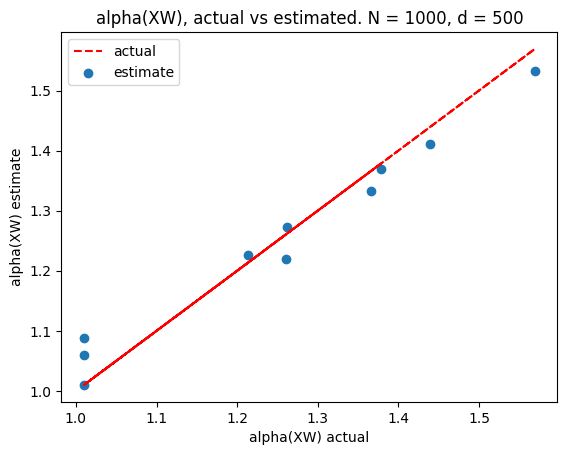

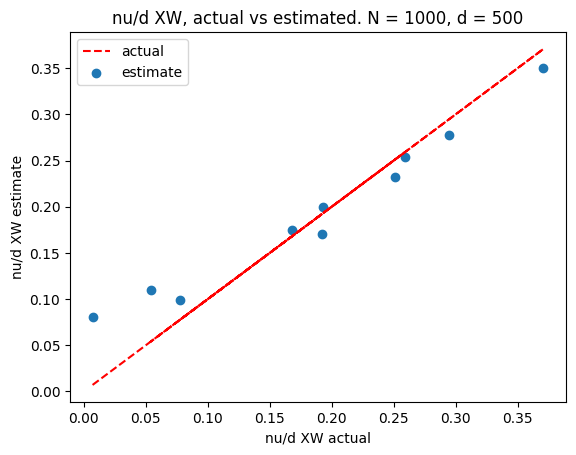

In [5]:
this_title = "alpha(XW), actual vs estimated. N = " + str(this_N) + ", d = " + str(this_d)
plt.title(this_title)
plt.plot(alpha_XW_vals, alpha_XW_vals, linestyle = "--", label="actual", color="red")
plt.scatter(alpha_XW_vals, alpha_XW_estimate_vals, label="estimate")
plt.xlabel("alpha(XW) actual")
plt.ylabel("alpha(XW) estimate")
plt.savefig('alpha_XW_actual_vs_estimated.pdf', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

this_title = "nu/d XW, actual vs estimated. N = " + str(this_N) + ", d = " + str(this_d)
plt.title(this_title)
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, linestyle = "--", label="actual", color="red")
plt.scatter(nu_over_d_XW_vals, nu_over_d_XW_estimate_vals, label="estimate")
plt.xlabel("nu/d XW actual")
plt.ylabel("nu/d XW estimate")
plt.savefig('nu_over_d_XW_actual_vs_estimated.pdf', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

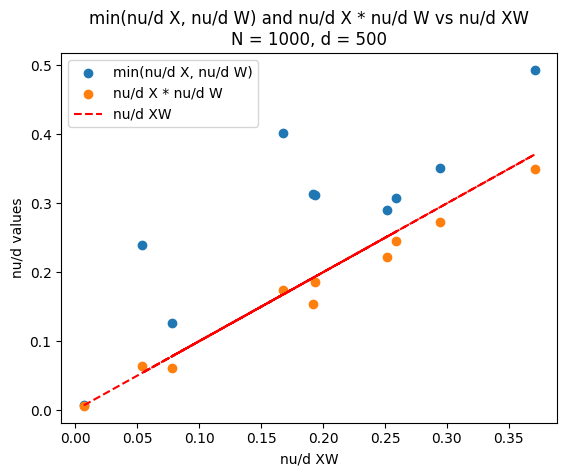

In [6]:
num_steps = len(nu_over_d_XW_vals)
min_nu_over_d_vals = np.zeros(num_steps)
product_nu_over_d_vals = np.zeros(num_steps)

for i in range(num_steps):
  this_nu_over_d_X = nu_over_d_X_vals[i]
  this_nu_over_d_W = nu_over_d_W_vals[i]
  min_nu_over_d_vals[i] = min(this_nu_over_d_X, this_nu_over_d_W)
  product_nu_over_d_vals[i] = this_nu_over_d_X * this_nu_over_d_W

this_title = "min(nu/d X, nu/d W) and nu/d X * nu/d W vs nu/d XW\n"
this_title = this_title + "N = " + str(this_N) + ", d = " + str(this_d)
plt.title(this_title)
plt.scatter(nu_over_d_XW_vals, min_nu_over_d_vals, label = "min(nu/d X, nu/d W)")
plt.scatter(nu_over_d_XW_vals, product_nu_over_d_vals, label = "nu/d X * nu/d W")
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, label = "nu/d XW", linestyle = "--", color="red")
plt.xlabel("nu/d XW")
plt.ylabel("nu/d values")
plt.legend()
plt.savefig('nu_over_d_min_X_W_and_X_times_W_vs_XW.pdf', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

# Experiment Two
### fix alpha_W = 2.0, allow alpha_X to vary

In [7]:

this_N = 1000
this_d = 500
alpha_W = 2.0

these_alpha_X = np.arange(1.1,4.1,0.25)
num_steps = len(these_alpha_X)

alpha_X_vals = np.zeros(num_steps)
alpha_W_vals = np.zeros(num_steps)
alpha_XW_vals = np.zeros(num_steps)
alpha_XW_estimate_vals = np.zeros(num_steps)
actual_alpha_X_vals = np.zeros(num_steps)
actual_alpha_W_vals = np.zeros(num_steps)
nu_over_d_X_vals = np.zeros(num_steps)
nu_over_d_W_vals = np.zeros(num_steps)
nu_over_d_XW_vals = np.zeros(num_steps)
nu_over_d_XW_estimate_vals = np.zeros(num_steps)
pp_dim_X_vals = np.zeros(num_steps)
pp_dim_W_vals = np.zeros(num_steps)
pp_dim_XW_vals = np.zeros(num_steps)

i = 0
for alpha_X in these_alpha_X:
  these_results = pp.product_alpha_experiment(this_N, this_d, alpha_X, alpha_W)

  print(i, alpha_X,these_results["alpha_XW"],these_results["alpha_XW_estimate"],
        these_results["nu_over_d_XW"],these_results["nu_over_d_XW_estimate"])

  alpha_X_vals[i] = alpha_X
  alpha_W_vals[i] = alpha_W
  alpha_XW_vals[i] = these_results["alpha_XW"]
  alpha_XW_estimate_vals[i] = these_results["alpha_XW_estimate"]
  actual_alpha_X_vals[i] = these_results["actual_alpha_X"]
  actual_alpha_W_vals[i] = these_results["actual_alpha_W"]
  nu_over_d_X_vals[i] = these_results["nu_over_d_X"]
  nu_over_d_W_vals[i] = these_results["nu_over_d_W"]
  nu_over_d_XW_vals[i] = these_results["nu_over_d_XW"]
  nu_over_d_XW_estimate_vals[i] = these_results["nu_over_d_XW_estimate"]
  pp_dim_X_vals[i] = these_results["pp_dim_X"]
  pp_dim_W_vals[i] = these_results["pp_dim_W"]
  pp_dim_XW_vals[i] = these_results["pp_dim_XW"]
  i+=1

 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
0 1.1 1.0100000000000002 1.0100000015394706 0.030967723933508228 0.08072615152946486
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
1 1.35 1.0100000000000002 1.061891381998066 0.05652064196349928 0.09951227898184234
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
2 1.6 1.2523193816460643 1.2450331089681559 0.18811721927413036 0.18425109753268923
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
3 1.85 1.3555907446248203 1.2895174900001323 0.24561105290885232 0.20829522235940634
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds 

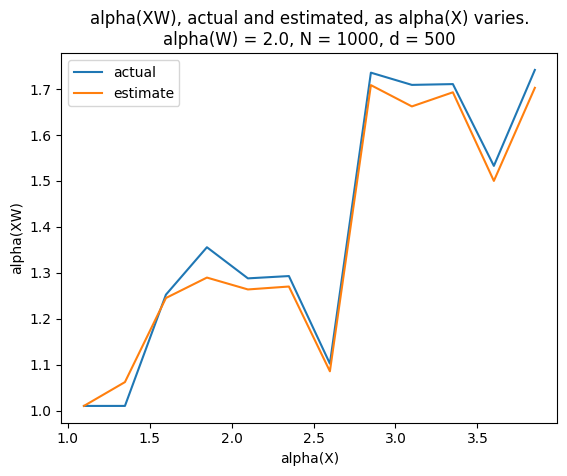

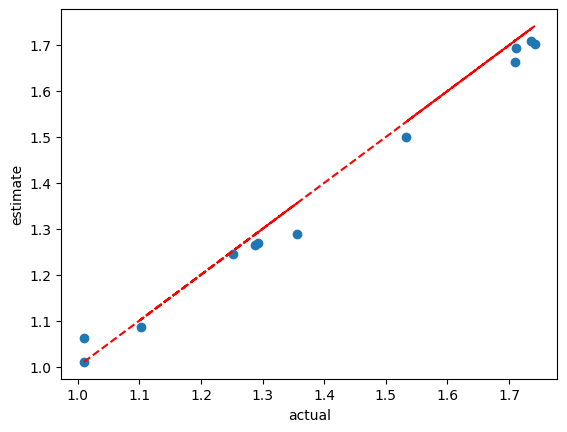

In [8]:
this_title = "alpha(XW), actual and estimated, as alpha(X) varies.\n"
this_title = this_title + "alpha(W) = " + str(alpha_W)
this_title = this_title + ", N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(alpha_X_vals, alpha_XW_vals, label="actual")
plt.plot(alpha_X_vals, alpha_XW_estimate_vals, label="estimate")
plt.xlabel("alpha(X)")
plt.ylabel("alpha(XW)")
plt.legend()
#plt.savefig('alpha_W_2_0_alpha_XW_actual_and_estimated_vs_alpha_X.pdf', dpi=300, bbox_inches='tight')
plt.title(this_title)
plt.show()

plt.scatter(alpha_XW_vals, alpha_XW_estimate_vals)
plt.plot(alpha_XW_vals, alpha_XW_vals, linestyle = "--", label="actual", color="red")
plt.xlabel("actual")
plt.ylabel("estimate")
plt.show()

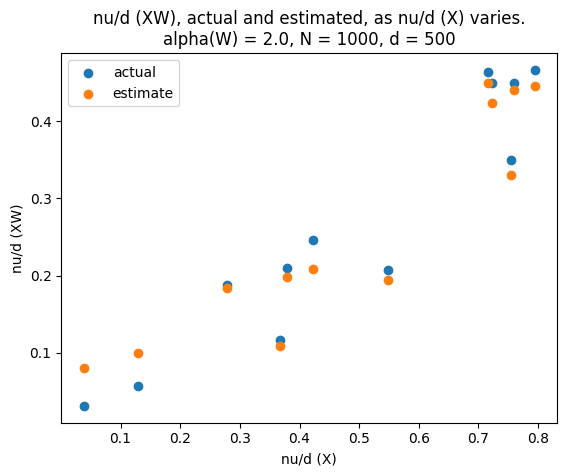

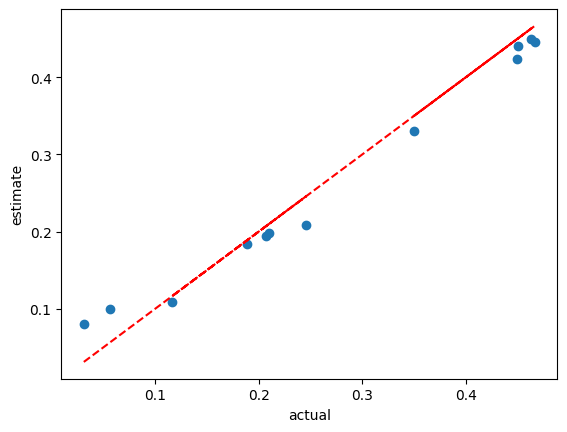

In [9]:
this_title = "nu/d (XW), actual and estimated, as nu/d (X) varies.\n"
this_title = this_title + "alpha(W) = " + str(alpha_W)
this_title = this_title + ", N = " + str(this_N) + ", d = " + str(this_d)
plt.scatter(nu_over_d_X_vals, nu_over_d_XW_vals, label="actual")
plt.scatter(nu_over_d_X_vals, nu_over_d_XW_estimate_vals, label="estimate")
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d (XW)")
plt.legend()
plt.title(this_title)
#plt.savefig('alpha_W_2_0_nu_over_d_XW_actual_and_estimated_vs_nu_over_d_X.pdf', dpi=300, bbox_inches='tight')
plt.show()

plt.scatter(nu_over_d_XW_vals, nu_over_d_XW_estimate_vals)
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, linestyle = "--", label="actual", color="red")
plt.xlabel("actual")
plt.ylabel("estimate")
plt.show()

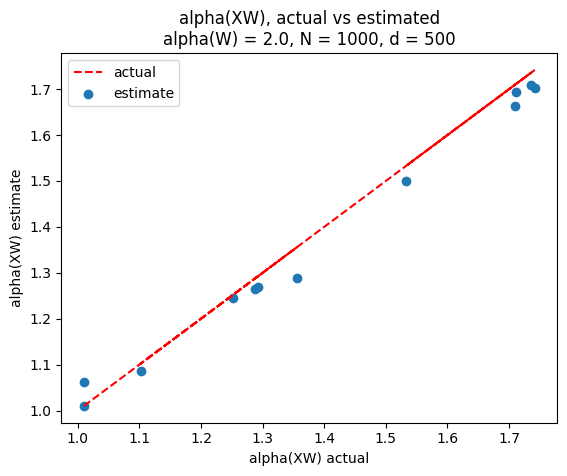

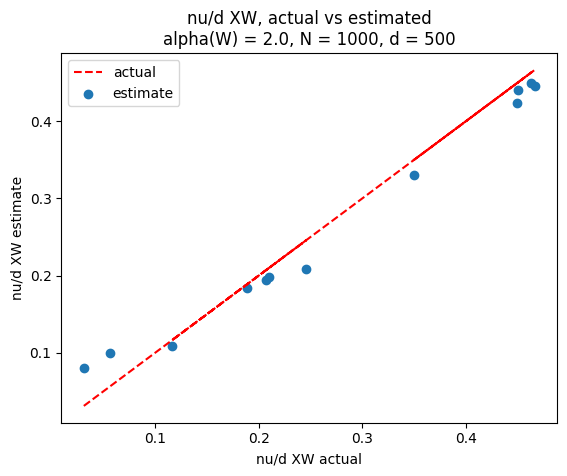

In [10]:
this_title = "alpha(XW), actual vs estimated\n"
this_title = this_title + "alpha(W) = " + str(alpha_W) + ", N = " + str(this_N) + ", d = " + str(this_d)
plt.title(this_title)
plt.plot(alpha_XW_vals, alpha_XW_vals, linestyle = "--", label="actual", color="red")
plt.scatter(alpha_XW_vals, alpha_XW_estimate_vals, label="estimate")
plt.xlabel("alpha(XW) actual")
plt.ylabel("alpha(XW) estimate")
#plt.savefig('alpha_W_1_0_alpha_XW_actual_vs_estimate.pdf', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

this_title = "nu/d XW, actual vs estimated\n"
this_title = this_title + "alpha(W) = " + str(alpha_W) + ", N = " + str(this_N) + ", d = " + str(this_d)
plt.title(this_title)
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, linestyle = "--", label="actual", color="red")
plt.scatter(nu_over_d_XW_vals, nu_over_d_XW_estimate_vals, label="estimate")
plt.xlabel("nu/d XW actual")
plt.ylabel("nu/d XW estimate")
#plt.savefig('alpha_W_1_0_nu_over_d_XW_actual_vs_estimate.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('.pdf', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

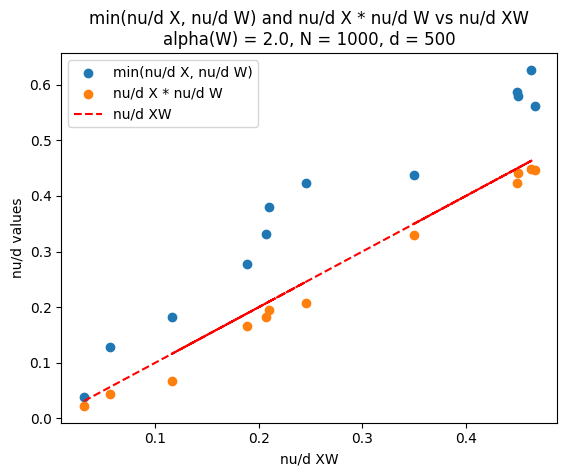

In [11]:

num_steps = len(nu_over_d_XW_vals)

min_nu_over_d_vals = np.zeros(num_steps)
product_nu_over_d_vals = np.zeros(num_steps)

for i in range(num_steps):
  this_nu_over_d_X = nu_over_d_X_vals[i]
  this_nu_over_d_W = nu_over_d_W_vals[i]
  min_nu_over_d_vals[i] = min(this_nu_over_d_X, this_nu_over_d_W)
  product_nu_over_d_vals[i] = this_nu_over_d_X * this_nu_over_d_W

this_title = "min(nu/d X, nu/d W) and nu/d X * nu/d W vs nu/d XW\n"
this_title = this_title + "alpha(W) = " + str(alpha_W)
this_title = this_title + ", N = " + str(this_N) + ", d = " + str(this_d)
plt.title(this_title)
plt.scatter(nu_over_d_XW_vals, min_nu_over_d_vals, label = "min(nu/d X, nu/d W)")
plt.scatter(nu_over_d_XW_vals, product_nu_over_d_vals, label = "nu/d X * nu/d W")
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, label = "nu/d XW", linestyle = "--", color="red")
plt.xlabel("nu/d XW")
plt.ylabel("nu/d values")
plt.legend()
#plt.savefig('alpha_W_1_0_nu_over_d_min_X_W_and_X_times_W_vs_XW.pdf', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

# Experiment Three
### fix alpha_W = 3.5, allow alpha_X to vary

In [12]:

# fix alpha_W = 3.5, allow alpha_X to vary

this_N = 1000
this_d = 500
alpha_W = 3.5
these_alpha_X = np.arange(1.1,4.1,0.25)
num_steps = len(these_alpha_X)

alpha_X_vals = np.zeros(num_steps)
alpha_W_vals = np.zeros(num_steps)
alpha_XW_vals = np.zeros(num_steps)
alpha_XW_estimate_vals = np.zeros(num_steps)
actual_alpha_X_vals = np.zeros(num_steps)
actual_alpha_W_vals = np.zeros(num_steps)
nu_over_d_X_vals = np.zeros(num_steps)
nu_over_d_W_vals = np.zeros(num_steps)
nu_over_d_XW_vals = np.zeros(num_steps)
nu_over_d_XW_estimate_vals = np.zeros(num_steps)
pp_dim_X_vals = np.zeros(num_steps)
pp_dim_W_vals = np.zeros(num_steps)
pp_dim_XW_vals = np.zeros(num_steps)

i = 0
for alpha_X in these_alpha_X:
  these_results = pp.product_alpha_experiment(this_N, this_d, alpha_X, alpha_W)

  print(i, alpha_X,these_results["alpha_XW"],these_results["alpha_XW_estimate"],
        these_results["nu_over_d_XW"],these_results["nu_over_d_XW_estimate"])

  alpha_X_vals[i] = alpha_X
  alpha_W_vals[i] = alpha_W
  alpha_XW_vals[i] = these_results["alpha_XW"]
  alpha_XW_estimate_vals[i] = these_results["alpha_XW_estimate"]
  actual_alpha_X_vals[i] = these_results["actual_alpha_X"]
  actual_alpha_W_vals[i] = these_results["actual_alpha_W"]
  nu_over_d_X_vals[i] = these_results["nu_over_d_X"]
  nu_over_d_W_vals[i] = these_results["nu_over_d_W"]
  nu_over_d_XW_vals[i] = these_results["nu_over_d_XW"]
  nu_over_d_XW_estimate_vals[i] = these_results["nu_over_d_XW_estimate"]
  pp_dim_X_vals[i] = these_results["pp_dim_X"]
  pp_dim_W_vals[i] = these_results["pp_dim_W"]
  pp_dim_XW_vals[i] = these_results["pp_dim_XW"]
  i +=1

 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
0 1.1 1.2675437388714705 1.2546299095187625 0.19628991698578385 0.18934944046719074
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
1 1.35 1.2709988380731032 1.2690921981407783 0.19816174604867554 0.19712804898015426
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
2 1.6 1.0100000000000002 1.0100000015394706 0.017396478969829227 0.08072615152946486
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
3 1.85 1.4961924843594465 1.4838836391849006 0.3281105136285497 0.32085055867740137
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds 

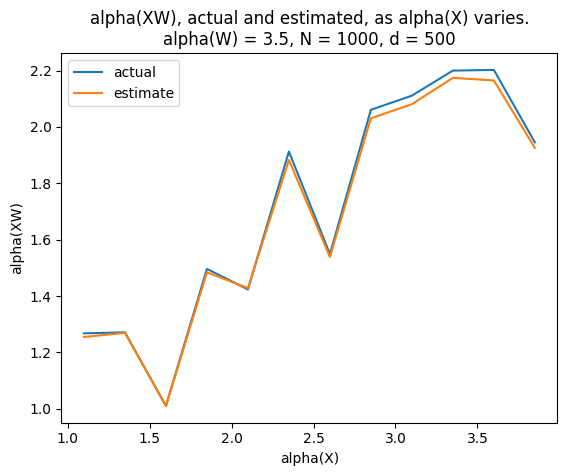

In [13]:
this_title = "alpha(XW), actual and estimated, as alpha(X) varies.\n"
this_title = this_title + "alpha(W) = " + str(alpha_W)
this_title = this_title + ", N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(alpha_X_vals, alpha_XW_vals, label="actual")
plt.plot(alpha_X_vals, alpha_XW_estimate_vals, label="estimate")
plt.xlabel("alpha(X)")
plt.ylabel("alpha(XW)")
plt.legend()
plt.title(this_title)
#plt.savefig('alpha_W_2_5_alpha_XW_actual_and_estimated_vs_alpha_X.pdf', dpi=300, bbox_inches='tight')
plt.show()

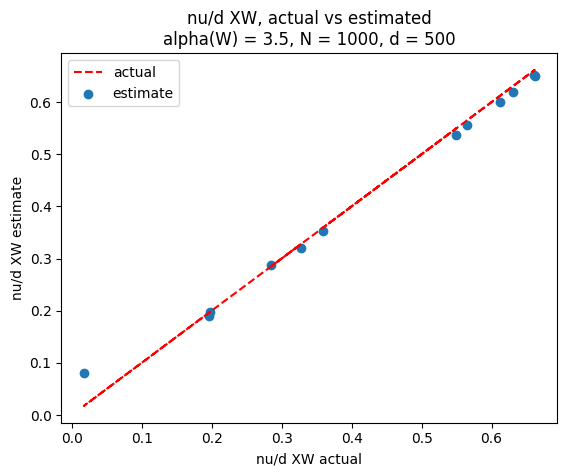

In [14]:
this_title = "nu/d XW, actual vs estimated\n"
this_title = this_title + "alpha(W) = " + str(alpha_W) + ", N = " + str(this_N) + ", d = " + str(this_d)
plt.title(this_title)
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, linestyle = "--", label="actual", color="red")
plt.scatter(nu_over_d_XW_vals, nu_over_d_XW_estimate_vals, label="estimate")
plt.xlabel("nu/d XW actual")
plt.ylabel("nu/d XW estimate")
plt.legend()
#plt.savefig('alpha_W_2_5_nu_over_d_XW_actual_vs_estimate.pdf', dpi=300, bbox_inches='tight')
plt.show()

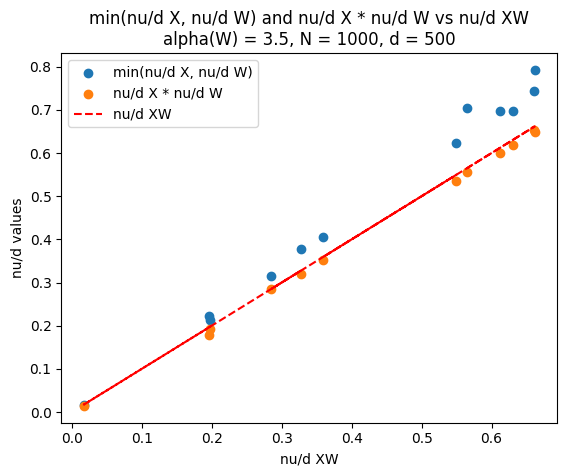

In [15]:

num_steps = len(nu_over_d_XW_vals)

min_nu_over_d_vals = np.zeros(num_steps)
product_nu_over_d_vals = np.zeros(num_steps)

for i in range(len(nu_over_d_XW_vals)):
  this_nu_over_d_X = nu_over_d_X_vals[i]
  this_nu_over_d_W = nu_over_d_W_vals[i]
  min_nu_over_d_vals[i] = min(this_nu_over_d_X, this_nu_over_d_W)
  product_nu_over_d_vals[i] = this_nu_over_d_X * this_nu_over_d_W

this_title = "min(nu/d X, nu/d W) and nu/d X * nu/d W vs nu/d XW\n"
this_title = this_title + "alpha(W) = " + str(alpha_W)
this_title = this_title + ", N = " + str(this_N) + ", d = " + str(this_d)
plt.title(this_title)
plt.scatter(nu_over_d_XW_vals, min_nu_over_d_vals, label = "min(nu/d X, nu/d W)")
plt.scatter(nu_over_d_XW_vals, product_nu_over_d_vals, label = "nu/d X * nu/d W")
plt.plot(nu_over_d_XW_vals, nu_over_d_XW_vals, label = "nu/d XW", linestyle = "--", color="red")
plt.xlabel("nu/d XW")
plt.ylabel("nu/d values")
plt.legend()
#plt.savefig('alpha_W_2_5_nu_over_d_min_X_W_and_X_times_W_vs_XW.pdf', dpi=300, bbox_inches='tight')
plt.show()

[]

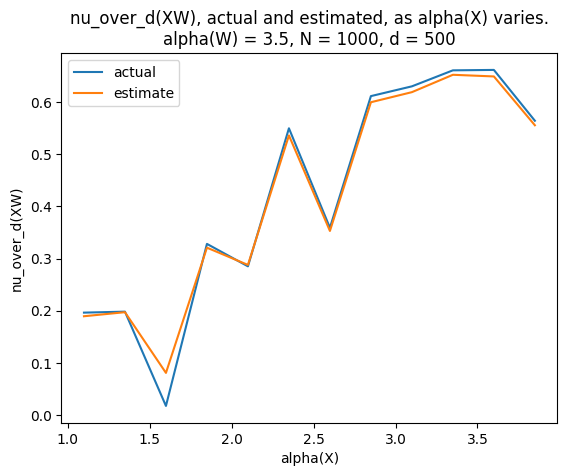

In [16]:
this_title = "nu_over_d(XW), actual and estimated, as alpha(X) varies.\n"
this_title = this_title + "alpha(W) = " + str(alpha_W)
this_title = this_title + ", N = " + str(this_N) + ", d = " + str(this_d)

plt.plot(alpha_X_vals, nu_over_d_XW_vals, label="actual")
plt.plot(alpha_X_vals, nu_over_d_XW_estimate_vals, label="estimate")
plt.xlabel("alpha(X)")
plt.ylabel("nu_over_d(XW)")
plt.legend()
plt.title(this_title)
plt.plot()

# Experiment Four
### fix alpha_W = 1.5, allow alpha_X to vary

In [17]:
# fix alpha_W = 1.5, allow alpha_X to vary

this_N = 1000
this_d = 500
alpha_W = 1.5
these_alpha_X = np.arange(0.1,4.1,0.25)
num_steps = len(these_alpha_X)

alpha_X_vals = np.zeros(num_steps)
alpha_W_vals = np.zeros(num_steps)
alpha_XW_vals = np.zeros(num_steps)
alpha_XW_estimate_vals = np.zeros(num_steps)
actual_alpha_X_vals = np.zeros(num_steps)
actual_alpha_W_vals = np.zeros(num_steps)
nu_over_d_X_vals = np.zeros(num_steps)
nu_over_d_W_vals = np.zeros(num_steps)
nu_over_d_XW_vals = np.zeros(num_steps)
nu_over_d_XW_estimate_vals = np.zeros(num_steps)
pp_dim_X_vals = np.zeros(num_steps)
pp_dim_W_vals = np.zeros(num_steps)
pp_dim_XW_vals = np.zeros(num_steps)

i = 0
for alpha_X in these_alpha_X:
  these_results = pp.product_alpha_experiment(this_N, this_d, alpha_X, alpha_W)

  print(i, alpha_X,these_results["alpha_XW"],these_results["alpha_XW_estimate"],
        these_results["nu_over_d_XW"],these_results["nu_over_d_XW_estimate"])

  alpha_X_vals[i] = alpha_X
  alpha_W_vals[i] = alpha_W
  alpha_XW_vals[i] = these_results["alpha_XW"]
  alpha_XW_estimate_vals[i] = these_results["alpha_XW_estimate"]
  actual_alpha_X_vals[i] = these_results["actual_alpha_X"]
  actual_alpha_W_vals[i] = these_results["actual_alpha_W"]
  nu_over_d_X_vals[i] = these_results["nu_over_d_X"]
  nu_over_d_W_vals[i] = these_results["nu_over_d_W"]
  nu_over_d_XW_vals[i] = these_results["nu_over_d_XW"]
  nu_over_d_XW_estimate_vals[i] = these_results["nu_over_d_XW_estimate"]
  pp_dim_X_vals[i] = these_results["pp_dim_X"]
  pp_dim_W_vals[i] = these_results["pp_dim_W"]
  pp_dim_XW_vals[i] = these_results["pp_dim_XW"]
  i +=1

 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
0 0.1 1.0100000000000002 1.0100000015394706 0.00380010269993606 0.08072615152946486
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
1 0.35 1.0100000000000002 1.0100000015394706 0.002003516049098945 0.08072615152946486
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
2 0.6 1.0100000000000002 1.0100000015394706 0.012402320939331614 0.08072615152946486
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpolation thresholds **
3 0.8499999999999999 1.0100000000000002 1.0100000015394706 0.004343956557522415 0.08072615152946486
 ** generate_square_weight_matrix: using GPU **
** estimate_product_nu_over_d: use new alpha - check the interpol

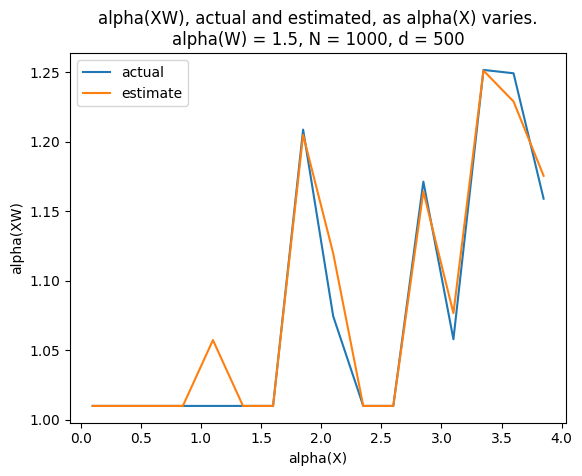

In [18]:
this_title = "alpha(XW), actual and estimated, as alpha(X) varies.\n"
this_title = this_title + "alpha(W) = " + str(alpha_W)
this_title = this_title + ", N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(alpha_X_vals, alpha_XW_vals, label="actual")
plt.plot(alpha_X_vals, alpha_XW_estimate_vals, label="estimate")
plt.xlabel("alpha(X)")
plt.ylabel("alpha(XW)")
plt.legend()
plt.title(this_title)
#plt.savefig('alpha_W_0_5_alpha_XW_actual_and_estimated_vs_alpha_X.pdf', dpi=300, bbox_inches='tight')
plt.show()